# Phenology calibration against observed dates (winter wheat)

This example calibrates torchcrop's **Lintul5** phenology against _observed_
winter-wheat development dates for the 18-location
[Brandenburg dataset](https://github.com/geonextgis/torchcrop/tree/main/docs/examples/data/brandenburg),
using **`torchcrop.calibration`**. Unlike the
[constraint-aware calibration example](https://geonextgis.github.io/torchcrop/examples/04_calibration/calibration_%28winter_wheat%29/),
which recovers known parameters from a synthetic twin, this one is a full
end-to-end workflow on real observations: prepare the data, fit the thermal-time
parameters by gradient descent, re-run the model, and compare observed against
simulated phenology.

Three crop parameters set the pace of development, and each one controls one
observable date:

| Parameter | Symbol | Unit | Controls                                | Observed counterpart |
| --------- | ------ | ---- | --------------------------------------- | -------------------- |
| `tsumem`  | TSUMEM | °C d | thermal time from sowing to emergence   | emergence date       |
| `tsum1`   | TSUM1  | °C d | thermal time from emergence to anthesis | flowering date       |
| `tsum2`   | TSUM2  | °C d | thermal time from anthesis to maturity  | maturity date        |

Lintul5 drives DVS from temperature alone here (the bundled wheat preset has
`IDSL = 0`, so neither photoperiod nor vernalisation modulates the rate), and
the development rate carries **no** dependence on water or nutrient stress.
Phenology is therefore identifiable from the three dates alone, and the
production level (`IOPT`) does not affect the fit — we run in potential mode so
the accompanying LAI and biomass trajectories are unstressed.

The one piece that needs care is the **loss**. The observations are calendar
dates, but the model returns a DVS _trajectory_; §3 turns the trajectory into a
differentiable date so the day error can be back-propagated all the way to
`tsum1`.


## Import libraries


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from torch.utils.data import Dataset

from torchcrop import (
    CalibrationManager,
    CropParameters,
    Lintul5Model,
    ParameterSpec,
    SiteParameters,
    SoilParameters,
    WeatherDriver,
)

plt.rcParams["font.family"] = "DeJavu Serif"
plt.rcParams["font.serif"] = "Times New Roman"

DATA_DIR = Path("../data", "brandenburg", "torchcrop")
DTYPE = torch.float64        # calibrate in double precision for clean gradients

# The batch is small (18 sites) and the time loop is sequential, so intra-op
# threading costs more than it saves; one thread is the fastest setting here.
torch.set_num_threads(1)
torch.manual_seed(0)

## 1. Observed phenology

The observations come from a NUTS-3 winter-wheat phenology table (sowing,
emergence, flowering and maturity dates per region and harvest year). Only the
regions **and** seasons that the example weather series can actually drive are
usable, so the table is filtered on two conditions:

1. `NUTS_ID` appears in `site/site.csv` (the 18 Brandenburg regions), and
2. the whole sowing → maturity window falls inside the weather record.

The filtered extract is stored next to the other example inputs as
`data/brandenburg/torchcrop/calibration/winter_wheat_phenology.csv`; the cell
below regenerates it from the source table if it is missing.


In [2]:
# Weather window actually available in the example data.
weather_dates = pd.read_csv(DATA_DIR / "weather" / "0.csv", parse_dates=["Date"])["Date"]
WEATHER_START, WEATHER_END = weather_dates.min(), weather_dates.max()
print(f"weather record: {WEATHER_START.date()} to {WEATHER_END.date()}")

site_table = pd.read_csv(DATA_DIR / "site" / "site.csv")
print(f"locations: {len(site_table)} Brandenburg NUTS-3 regions")

weather record: 2020-01-01 to 2021-12-31
locations: 18 Brandenburg NUTS-3 regions


In [3]:
# Provenance of the observations. The extract below is committed with the
# example data, so this path is only needed to regenerate it.
SOURCE_PHENOLOGY = Path(
    "/beegfs/halder/GITHUB/RESEARCH/crop-yield-forecasting-germany"
    "/data/processed/winter_wheat/winter_wheat_phenology.csv"
)
PHENOLOGY_CSV = DATA_DIR / "calibration" / "winter_wheat_phenology.csv"

EVENTS = ["emergence", "flowering", "maturity"]


def extract_phenology(source, site_table, weather_start, weather_end):
    """Select the phenology rows matching the torchcrop example dataset.

    Keeps the regions listed in ``site.csv`` and the harvest years spanned by
    the weather record, and flags the seasons whose full sowing → maturity
    window is covered by that record.

    Args:
        source: Path to the full NUTS-3 winter-wheat phenology table.
        site_table: ``site.csv`` as a DataFrame (``location``, ``NUTS_ID``, …).
        weather_start: First date of the example weather series.
        weather_end: Last date of the example weather series.

    Returns:
        DataFrame with one row per (location, harvest year), the four event
        dates and day-of-year values, and a ``weather_covered`` flag.
    """
    date_cols = [f"{e}_date" for e in ["sowing"] + EVENTS]
    doy_cols = [f"{e}_doy" for e in ["sowing"] + EVENTS]

    raw = pd.read_csv(source)
    years = range(weather_start.year, weather_end.year + 1)
    keep = raw.NUTS_ID.isin(site_table.NUTS_ID) & raw.harvest_year.isin(years)
    # ``NUTS_NAME`` is taken from site.csv, which carries the authoritative
    # region names for these codes.
    out = site_table[["location", "NUTS_ID", "NUTS_NAME"]].merge(
        raw.loc[keep, ["NUTS_ID", "harvest_year", *date_cols, *doy_cols]],
        on="NUTS_ID",
    )
    out["weather_covered"] = (
        pd.to_datetime(out.sowing_date).between(weather_start, weather_end)
        & pd.to_datetime(out.maturity_date).between(weather_start, weather_end)
    )
    return out.sort_values(["harvest_year", "location"]).reset_index(drop=True)


if not PHENOLOGY_CSV.exists():
    PHENOLOGY_CSV.parent.mkdir(parents=True, exist_ok=True)
    extract_phenology(
        SOURCE_PHENOLOGY, site_table, WEATHER_START, WEATHER_END
    ).to_csv(PHENOLOGY_CSV, index=False)

phenology = pd.read_csv(PHENOLOGY_CSV)
phenology.groupby("harvest_year").weather_covered.agg(["count", "sum"])

,count,sum
harvest_year,,
2020,18,0
2021,18,18


Both harvest years matched by `NUTS_ID` are listed, but only **2021** is
usable: the 2020 crop was sown in autumn 2019, before the weather record
begins. That leaves 18 site-seasons — one per region — with a complete
sowing → maturity window.


In [4]:
obs = phenology[phenology.weather_covered].reset_index(drop=True)
HARVEST_YEAR = int(obs.harvest_year.iat[0])
print(f"calibration set: {len(obs)} site-seasons, harvest year {HARVEST_YEAR}")

obs[["location", "NUTS_ID", "NUTS_NAME", "sowing_date", "emergence_date",
     "flowering_date", "maturity_date"]]

calibration set: 18 site-seasons, harvest year 2021


,location,NUTS_ID,NUTS_NAME,sowing_date,emergence_date,flowering_date,maturity_date
0,0,DE40F,Prignitz,2020-09-26,2020-10-10,2021-06-07,2021-08-02
1,1,DE40I,Uckermark,2020-09-10,2020-09-24,2021-06-05,2021-07-27
2,2,DE40A,Oberhavel,2020-09-28,2020-10-10,2021-06-06,2021-08-02
3,3,DE405,Barnim,2020-09-18,2020-09-29,2021-06-02,2021-07-24
4,4,DE40D,Ostprignitz-Ruppin,2020-10-06,2020-10-21,2021-06-04,2021-07-24
5,5,DE409,Märkisch-Oderland,2020-10-06,2020-10-20,2021-06-01,2021-07-27
6,6,DE408,Havelland,2020-10-08,2020-10-13,2021-06-02,2021-08-08
7,7,DE40E,Potsdam-Mittelmark,2020-10-04,2020-10-14,2021-05-23,2021-07-14
8,8,DE404,"Potsdam, Kreisfreie Stadt",2020-10-12,2020-10-26,2021-05-27,2021-07-27
9,9,DE406,Dahme-Spreewald,2020-10-12,2020-10-31,2021-06-04,2021-07-31


### Simulation window and day indices

The weather record runs for two full calendar years, but the 2021 crop only
needs the window that brackets the season. Trimming it to _(earliest sowing −
10 d)_ … _(latest maturity + 45 d)_ roughly halves the length of the time loop —
worth it because the loop is re-run on every optimizer step.

Every observed date is then expressed as a **day index** relative to the first
simulated day, which is the unit the model's trajectories are indexed in.


In [5]:
SIM_START = (pd.to_datetime(obs.sowing_date).min() - pd.Timedelta(days=10)).normalize()
SIM_END = min(pd.to_datetime(obs.maturity_date).max() + pd.Timedelta(days=45), WEATHER_END)
START_DOY = int(SIM_START.dayofyear)

for event in ["sowing", *EVENTS]:
    obs[f"{event}_day"] = (pd.to_datetime(obs[f"{event}_date"]) - SIM_START).dt.days

print(f"simulation window: {SIM_START.date()} to {SIM_END.date()} "
      f"({(SIM_END - SIM_START).days + 1} days), start_doy={START_DOY}")
obs[["location", "sowing_day", "emergence_day", "flowering_day", "maturity_day"]].T

simulation window: 2020-08-31 to 2021-09-24 (390 days), start_doy=244


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
location,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
sowing_day,26,10,28,18,36,36,38,34,42,42,33,33,34,15,37,45,65,32
emergence_day,40,24,40,29,51,50,43,44,56,61,42,42,44,28,50,55,74,46
flowering_day,280,278,279,275,277,274,275,265,269,277,268,268,265,260,278,260,255,279
maturity_day,336,330,336,327,327,330,342,317,330,334,332,332,317,329,332,327,344,335


## 2. Model inputs

Weather, soil and site inputs are read with the same `TorchCropDataset` /
`collate_torchcrop` pair used by the other Brandenburg examples, extended with
a date window so only the simulated period is loaded. Two things differ from
those runs:

- **Sowing dates come from the observations.** `site.csv` carries a constant
  `IDPL = 270` for every region; here each location gets its _observed_ sowing
  day-of-year instead. `IDPL` is a calendar switch — it is on the model's
  non-differentiable list — so it is treated as a given input, not a
  calibration target.
- **Potential production** is used — the preset default `IOPT = 1`. DVS is
  stress-independent, so this changes nothing about the fit; it just keeps the
  companion LAI and biomass trajectories unstressed.


In [6]:
class TorchCropDataset(Dataset):
    """Reads per-location weather, soil, and site data for torchcrop.

    Directory layout (under ``DATA_DIR``)::

        weather/<location>.csv   daily forcing, one file per location
        soil/soil.csv            one row per location, indexed by ``location``
        site/site.csv            one row per location, indexed by ``location``

    ``__getitem__`` returns a single sample as a dict with:

        * ``weather`` : ``[T, 8]`` float tensor in torchcrop channel order
          (DOY, davtmp, tmin, tmax, irrad, rain, vp, wind), restricted to
          ``[start_date, end_date]``
        * ``soil``    : dict of scalar floats keyed by ``SoilParameters`` field
        * ``site``    : dict of scalar floats keyed by ``SiteParameters`` field

    Use `collate_torchcrop` as the DataLoader ``collate_fn`` to assemble a
    batch into ready-to-run ``WeatherDriver`` / ``SoilParameters`` /
    ``SiteParameters`` objects.

    Args:
        weather_dir: Directory holding ``<location>.csv`` weather files.
        soil_dir: Directory holding ``soil.csv``.
        site_dir: Directory holding ``site.csv``.
        locations: Locations to load, in the order the batch should carry
            them. ``None`` loads every location present in both tables.
        start_date: First date to keep from each weather file.
        end_date: Last date to keep from each weather file.
        dtype: Target dtype for the assembled tensors.
    """

    # CSV weather columns, in the exact order torchcrop expects them.
    WEATHER_COLS = [
        "Date",          # -> doy
        "TempMean",      # -> davtmp (recomputed as (TempMin+TempMax)/2 below)
        "TempMin",       # -> tmin
        "TempMax",       # -> tmax
        "Radiation",     # -> irrad
        "Precipitation", # -> rain
        "VapPressure",   # -> vp
        "Windspeed",     # -> wind
    ]

    # soil.csv column -> SoilParameters field name
    SOIL_MAP = {
        "SMDRY": "wcad",       # air-dry volumetric water content [m³ m⁻³]
        "SMW": "wcwp",         # water content at wilting point [m³ m⁻³]
        "SMFC": "wcfc",        # water content at field capacity [m³ m⁻³]
        "SMO": "wcst",         # water content at saturation [m³ m⁻³]
        "CRAIRC": "crairc",    # critical air content for aeration [m³ m⁻³]
        "SMI": "wci",          # initial root-zone moisture content [m³ m⁻³]
        "SMLOWI": "wci_lower", # initial lower-zone (sub-soil) moisture [m³ m⁻³]
        "RDMSO": "rdmso",      # max rooting depth allowed by the soil [m]
        "RUNFR": "runfr",      # fraction of rainfall lost to surface runoff [0–1]
        "CFEV": "cfev",        # soil-evaporation correction factor [-] (1–4)
        "KSUB": "ksub",        # max percolation rate to deeper layers [mm d⁻¹]
        "NMINS": "nmini",      # initial mineralisable soil organic N [g N m⁻²]
        "PMINS": "pmini",      # initial mineralisable soil organic P [g P m⁻²]
        "KMINS": "kmini",      # initial mineralisable soil organic K [g K m⁻²]
        "RTNMINS": "rtnmins",  # daily N mineralisation fraction [d⁻¹]
        "RTPMINS": "rtpmins",  # daily P mineralisation fraction [d⁻¹]
        "RTKMINS": "rtkmins",  # daily K mineralisation fraction [d⁻¹]
    }

    # site.csv column -> SiteParameters field name
    SITE_MAP = {
        "LATITUDE": "latitude",
        "ALTITUDE": "altitude",
        "IDPL": "idpl",
        "CO2": "co2",
    }

    def __init__(self, weather_dir, soil_dir, site_dir, locations=None,
                 start_date=None, end_date=None, dtype=torch.float32):
        super().__init__()
        self.weather_dir = Path(weather_dir)
        self.dtype = dtype
        self.start_date = start_date
        self.end_date = end_date
        self.soil_data = pd.read_csv(
            Path(soil_dir) / "soil.csv"
        ).set_index("location")
        self.site_data = pd.read_csv(
            Path(site_dir) / "site.csv"
        ).set_index("location")
        if locations is None:
            locations = self.soil_data.index.intersection(self.site_data.index)
        self.locations = list(locations)

    def __len__(self):
        return len(self.locations)

    def _load_weather(self, location):
        df = pd.read_csv(
            self.weather_dir / f"{location}.csv", parse_dates=["Date"]
        )
        if self.start_date is not None:
            df = df[df.Date >= self.start_date]
        if self.end_date is not None:
            df = df[df.Date <= self.end_date]
        df = df[self.WEATHER_COLS].copy()
        # SIMPLACE drives phenology with TMPA = (TMIN+TMAX)/2 (Phenology.java:513),
        # not the measured TempMean; match it to reproduce the reference.
        df["TempMean"] = (df["TempMin"] + df["TempMax"]) / 2.0
        df["Radiation"] = df["Radiation"] / 1000.0   # kJ -> MJ m-2 d-1
        df["Date"] = df["Date"].dt.dayofyear          # date -> day-of-year
        return torch.as_tensor(df.values, dtype=self.dtype)  # [T, 8]

    def __getitem__(self, idx):
        location = self.locations[idx]

        weather = self._load_weather(location)

        srow = self.soil_data.loc[location]
        soil = {field: float(srow[col]) for col, field in self.SOIL_MAP.items()}

        trow = self.site_data.loc[location]
        site = {field: float(trow[col]) for col, field in self.SITE_MAP.items()}

        return {"weather": weather, "soil": soil, "site": site}


def collate_torchcrop(batch, dtype=torch.float32):
    """Collate samples into batched torchcrop driver/parameter objects.

    Args:
        batch: list of samples produced by `TorchCropDataset.__getitem__`.
        dtype: target dtype for the assembled tensors.

    Returns:
        Tuple ``(weather, soil_params, site_params)`` where ``weather`` is a
        `WeatherDriver` of shape ``[B, T, 8]`` and ``soil_params`` /
        ``site_params`` are batched dataclasses with ``[B]`` scalar fields.
    """
    # Weather: [B, T, 8]
    weather = torch.stack([s["weather"] for s in batch], dim=0).to(dtype)
    weather = WeatherDriver(weather)

    # Soil / site: stack each field across the batch into a [B] tensor.
    soil_fields = batch[0]["soil"].keys()
    soil_kwargs = {
        f: torch.tensor([s["soil"][f] for s in batch], dtype=dtype)
        for f in soil_fields
    }
    soil_params = SoilParameters(**soil_kwargs)

    site_fields = batch[0]["site"].keys()
    site_kwargs = {
        f: torch.tensor([s["site"][f] for s in batch], dtype=dtype)
        for f in site_fields
    }
    site_params = SiteParameters(**site_kwargs)

    return weather, soil_params, site_params

In [7]:
dataset = TorchCropDataset(
    weather_dir=DATA_DIR / "weather",
    soil_dir=DATA_DIR / "soil",
    site_dir=DATA_DIR / "site",
    locations=obs.location.tolist(),   # batch order follows `obs`
    start_date=SIM_START,
    end_date=SIM_END,
    dtype=DTYPE,
)
weather, soil_params, site_params = collate_torchcrop(
    [dataset[i] for i in range(len(dataset))], dtype=DTYPE
)
B, T = weather.batch_size, weather.n_days

# Observed sowing day-of-year drives the model's sowing latch, one per site.
site_params.idpl = torch.tensor(obs.sowing_doy.values, dtype=DTYPE)

crop_params = CropParameters(crop_name="wheat").to(dtype=DTYPE)
model = Lintul5Model(crop_params, soil_params, site_params)

print(f"batch: B={B} sites x T={T} days")
print(f"run mode: iopt={int(crop_params.iopt)} (potential production)")
print(f"preset phenology: tsumem={float(crop_params.tsumem):.0f}, "
      f"tsum1={float(crop_params.tsum1):.0f}, tsum2={float(crop_params.tsum2):.0f} °C d")

batch: B=18 sites x T=390 days
run mode: iopt=1 (potential production)
preset phenology: tsumem=60, tsum1=1050, tsum2=1000 °C d


## 3. From a DVS trajectory to a phenological date

The model returns a development-stage trajectory; the observations are dates.
To compare them, the _date at which a trajectory reaches a threshold_ has to be
computed in a way that carries a gradient.

For a non-decreasing trajectory $x_t$ and threshold $x^{\ast}$, let $t_0$ be
the last day below the threshold. Linear interpolation between $t_0$ and
$t_0 + 1$ gives the crossing day

$$
\hat{t}(x^{\ast}) = t_0 +
    \frac{x^{\ast} - x_{t_0}}{x_{t_0+1} - x_{t_0}}
$$

The index $t_0$ is a lookup (no gradient of its own), but $x_{t_0}$,
$x_{t_0+1}$ and $x^{\ast}$ are all tensors, so
$\partial \hat{t} / \partial \theta$
flows back through the trajectory into the crop parameters. The estimate is
also _exact_ — no smoothing bias — which matters because the quantity is
reported in days.

Each event uses its own trajectory and threshold:

| Event     | Trajectory                          | Threshold |
| --------- | ----------------------------------- | --------- |
| emergence | `tsump` (thermal time since sowing) | `tsumem`  |
| flowering | `dvs`                               | `1.0`     |
| maturity  | `dvs`                               | `2.0`     |

Emergence is read off `tsump` rather than `dvs` because DVS is pinned at 0
until the crop emerges — the emergence signal lives in the thermal-time clock,
and taking the threshold from `tsumem` is what gives that parameter its
gradient.


In [8]:
def crossing_day(x, threshold):
    """Differentiable day index at which ``x`` first reaches ``threshold``.

    Args:
        x: ``[B, T]`` non-decreasing trajectory (one row per site).
        threshold: Scalar or ``[B]`` threshold value, in the units of ``x``.

    Returns:
        ``[B]`` fractional day index of the crossing, linearly interpolated
        between the bracketing days. Sites that never cross return the last
        day of the window.
    """
    thr = torch.as_tensor(threshold, dtype=x.dtype, device=x.device).expand(x.shape[0])
    # Last day strictly below the threshold; the crossing lies in [t0, t0 + 1].
    t0 = ((x < thr.unsqueeze(1)).sum(dim=1) - 1).clamp(0, x.shape[1] - 2)
    x0 = x.gather(1, t0.unsqueeze(1)).squeeze(1)
    x1 = x.gather(1, (t0 + 1).unsqueeze(1)).squeeze(1)
    frac = ((thr - x0) / (x1 - x0).clamp(min=1e-9)).clamp(0.0, 1.0)
    return t0.to(x.dtype) + frac


def phenological_days(output, crop_params):
    """Simulated emergence / flowering / maturity days for a run.

    Args:
        output: `ModelOutput` from a full simulation.
        crop_params: The crop parameters the run used (supplies ``tsumem``).

    Returns:
        Dict of ``[B]`` tensors holding day indices relative to the first
        simulated day, keyed by event name.
    """
    # Drop the initial condition so index t is the state at the end of day t.
    tsump = torch.stack([s.tsump for s in output.states], dim=1)[:, 1:]  # [B, T]
    dvs = output.dvs[:, 1:]                                              # [B, T]
    return {
        "emergence": crossing_day(tsump, crop_params.tsumem),
        "flowering": crossing_day(dvs, 1.0),
        "maturity": crossing_day(dvs, 2.0),
    }


observed_days = {
    event: torch.tensor(obs[f"{event}_day"].values, dtype=DTYPE) for event in EVENTS
}


def event_errors(predicted, subset=None, label=""):
    """Bias / MAE / RMSE in days for each event.

    Args:
        predicted: Dict of ``[B]`` simulated day indices, keyed by event.
        subset: Optional index tensor selecting a subset of sites.
        label: Value written into the ``set`` column of the result.

    Returns:
        DataFrame with one row per event.
    """
    rows = []
    for event, pred in predicted.items():
        err = (pred - observed_days[event]).detach()
        if subset is not None:
            err = err[subset]
        rows.append({
            "set": label,
            "event": event,
            "bias_d": float(err.mean()),
            "MAE_d": float(err.abs().mean()),
            "RMSE_d": float(err.pow(2).mean().sqrt()),
        })
    return pd.DataFrame(rows).round(2)

## 4. Baseline run with the bundled preset

The `wheat` preset ships with `TSUM1 = 1050` and `TSUM2 = 1000` °C d — values
taken from a WOFOST data set for winter wheat in Ireland, the UK, the
Netherlands and northern Germany. Run it as-is on the Brandenburg sites to see
how far off it is before any fitting.


In [9]:
with torch.no_grad():
    baseline_out = model(weather, start_doy=START_DOY)
    baseline_days = phenological_days(baseline_out, crop_params)

baseline_dvs = baseline_out.dvs[:, 1:].numpy()          # kept for the plots below
baseline_errors = event_errors(baseline_days, label="preset")
baseline_errors

,set,event,bias_d,MAE_d,RMSE_d
0,preset,emergence,-8.53,8.53,9.21
1,preset,flowering,-30.92,32.77,36.54
2,preset,maturity,-25.83,25.83,26.88


Every event is simulated **too early** — flowering by about a month. That is
the expected signature of thermal-time parameters transferred from a milder
maritime climate to the continental Brandenburg sites: the same degree-day
totals are reached sooner.


## 5. Declare the calibration problem

A calibration problem is pure data: a list of `ParameterSpec` naming the free
parameters by dotted path, with the physical range each one is confined to.
`CalibrationManager` seeds an unconstrained latent per spec and maps it back
through a bijection on every step, so **every iterate stays inside the bounds**
without penalties or clipping.

The bounds below are generous but physical — roughly the span of published
winter-wheat values. The sites are split into a **training** set that the loss
sees and a held-out **test** set used only for evaluation, so the reported skill
is not just a measure of how well three parameters can absorb 18 sites.


In [10]:
specs = [
    ParameterSpec("crop.tsumem", bounds=(40.0, 300.0)),
    ParameterSpec("crop.tsum1", bounds=(900.0, 2000.0)),
    ParameterSpec("crop.tsum2", bounds=(700.0, 1800.0)),
]
cal = CalibrationManager(model, specs)
preset_values = cal.named_values()   # latents are seeded from the preset

# Site-wise split: 12 sites drive the loss, 6 are held out.
perm = torch.randperm(B, generator=torch.Generator().manual_seed(0))
train_idx, test_idx = perm[:12].sort().values, perm[12:].sort().values

print("initial (materialized) values:")
for name, value in preset_values.items():
    print(f"  {name:14s} = {value:8.1f} °C d")
print(f"\ntrain sites: {train_idx.tolist()}")
print(f"test sites : {test_idx.tolist()}")

initial (materialized) values:
  crop.tsumem    =     60.0 °C d
  crop.tsum1     =   1050.0 °C d
  crop.tsum2     =   1000.0 °C d

train sites: [0, 1, 2, 3, 4, 5, 7, 8, 9, 11, 13, 15]
test sites : [6, 10, 12, 14, 16, 17]


## 6. Optimize

The loop is ordinary PyTorch. `cal.materialize()` writes the constrained values
into `crop_params` before the forward pass, and the optimizer only ever sees
`cal.parameters()` — the latents.

The objective is the mean squared date error, in days², averaged over the three
events so each contributes equally:

$$
\mathcal{L} = \frac{1}{3}\sum_{e \in \{\text{em},\,\text{fl},\,\text{mat}\}}
              \frac{1}{|S_\text{train}|}
              \sum_{s \in S_\text{train}} \left(\hat{t}_{e,s} - t_{e,s}\right)^2
$$

Each step runs the full simulation and back-propagates through every day of the
window, so the loop takes a few minutes. Momentum is damped
(`betas=(0.8, 0.95)`): `tsum1` and `tsum2` both push the maturity date, and the
default momentum sends that pair on a long excursion before it settles.


In [11]:
N_STEPS = 80
optimizer = torch.optim.Adam(cal.parameters(), lr=0.12, betas=(0.8, 0.95))

history = {"rmse": [], **{name: [] for name in cal.named_values()}}

for step in range(N_STEPS):
    optimizer.zero_grad()

    cal.materialize()
    out = model(weather, start_doy=START_DOY)
    predicted = phenological_days(out, crop_params)

    loss = sum(
        (predicted[event] - observed_days[event])[train_idx].pow(2).mean()
        for event in EVENTS
    ) / len(EVENTS)

    loss.backward()
    optimizer.step()

    values = cal.named_values()
    history["rmse"].append(float(loss) ** 0.5)
    for name, value in values.items():
        history[name].append(value)

    if step % 5 == 0 or step == N_STEPS - 1:
        print(
            f"step={step:03d} | train RMSE={history['rmse'][-1]:6.2f} d | "
            f"tsumem={values['crop.tsumem']:6.1f} | "
            f"tsum1={values['crop.tsum1']:7.1f} | "
            f"tsum2={values['crop.tsum2']:7.1f}"
        )

step=000 | train RMSE= 28.68 d | tsumem=  62.3 | tsum1= 1066.2 | tsum2= 1026.9
step=005 | train RMSE= 20.33 d | tsumem=  78.3 | tsum1= 1167.1 | tsum2= 1173.3
step=010 | train RMSE= 11.78 d | tsumem= 102.8 | tsum1= 1291.5 | tsum2= 1316.9
step=015 | train RMSE= 11.61 d | tsumem= 134.8 | tsum1= 1396.9 | tsum2= 1411.6
step=020 | train RMSE= 14.72 d | tsumem= 163.5 | tsum1= 1444.2 | tsum2= 1443.0
step=025 | train RMSE= 14.94 d | tsumem= 173.4 | tsum1= 1437.0 | tsum2= 1427.0
step=030 | train RMSE= 13.16 d | tsumem= 166.4 | tsum1= 1404.9 | tsum2= 1391.5
step=035 | train RMSE= 11.38 d | tsumem= 159.3 | tsum1= 1381.4 | tsum2= 1355.2
step=040 | train RMSE= 10.73 d | tsumem= 158.8 | tsum1= 1378.9 | tsum2= 1324.4
step=045 | train RMSE= 10.17 d | tsumem= 161.4 | tsum1= 1385.0 | tsum2= 1293.5
step=050 | train RMSE=  9.78 d | tsumem= 160.5 | tsum1= 1391.4 | tsum2= 1258.0
step=055 | train RMSE=  8.82 d | tsumem= 159.9 | tsum1= 1391.1 | tsum2= 1188.0
step=060 | train RMSE=  8.19 d | tsumem= 160.6 | tsu

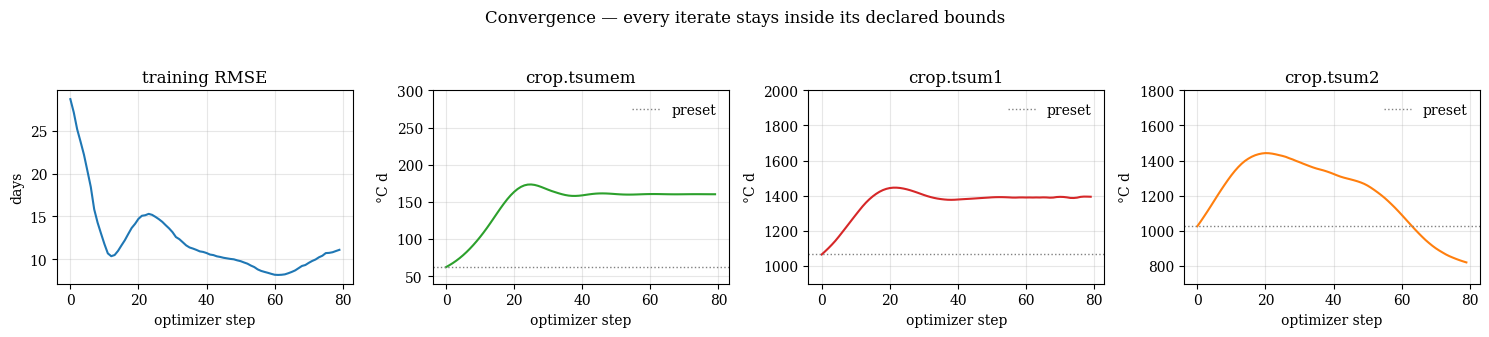

In [12]:
fig, ax = plt.subplots(1, 4, figsize=(15, 3.2))

ax[0].plot(history["rmse"], color="#1f77b4")
ax[0].set_title("training RMSE"); ax[0].set_ylabel("days")

for axis, (name, colour) in zip(
    ax[1:], zip(["crop.tsumem", "crop.tsum1", "crop.tsum2"],
                ["#2ca02c", "#d62728", "#ff7f0e"])
):
    lo, hi = next(s.bounds for s in specs if s.name == name)
    axis.plot(history[name], color=colour)
    axis.axhline(history[name][0], ls=":", c="grey", lw=1, label="preset")
    axis.set_ylim(lo, hi)
    axis.set_title(name); axis.set_ylabel("°C d"); axis.legend(frameon=False)

for axis in ax:
    axis.set_xlabel("optimizer step"); axis.grid(alpha=0.3)

fig.suptitle("Convergence — every iterate stays inside its declared bounds", y=1.04)
plt.tight_layout(); plt.show()

## 7. Run the model with the calibrated parameters

`materialize()` leaves the fitted values in `crop_params`, so the calibrated
model is just the same model run again. The comparison below reports both the
training sites and the held-out ones.


In [13]:
cal.materialize()
with torch.no_grad():
    calibrated_out = model(weather, start_doy=START_DOY)
    calibrated_days = phenological_days(calibrated_out, crop_params)

calibrated_dvs = calibrated_out.dvs[:, 1:].numpy()

fitted_values = cal.named_values()
summary = pd.DataFrame({
    "preset [°C d]": preset_values,
    "calibrated [°C d]": fitted_values,
}).round(1)
summary["change"] = (summary["calibrated [°C d]"] - summary["preset [°C d]"]).round(1)
summary

,preset [°C d],calibrated [°C d],change
crop.tsumem,60.0,160.3,100.3
crop.tsum1,1050.0,1394.7,344.7
crop.tsum2,1000.0,821.3,-178.7


In [15]:
errors = pd.concat([
    event_errors(baseline_days, label="preset — all"),
    event_errors(calibrated_days, label="calibrated — all"),
    event_errors(calibrated_days, subset=train_idx, label="calibrated — train"),
    event_errors(calibrated_days, subset=test_idx, label="calibrated — test"),
])
errors.pivot(index="event", columns="set", values=["bias_d", "MAE_d", "RMSE_d"])

bias_d                                                    \
set       calibrated — all calibrated — test calibrated — train preset — all   
event                                                                          
emergence             1.37              5.29              -0.59        -8.53   
flowering             4.96             10.57               2.15       -30.92   
maturity            -12.78            -11.83             -13.25       -25.83   

                     MAE_d                                                    \
set       calibrated — all calibrated — test calibrated — train preset — all   
event                                                                          
emergence             3.98              5.93               3.01         8.53   
flowering             9.69             10.85               9.11        32.77   
maturity             12.78             11.83              13.25        25.83   

                    RMSE_d                                                    
set       calibrated — all calibrated — test calibrated — train preset — all  
event                                                                         
emergence             5.30              7.54               3.71         9.21  
flowering            13.37             16.87              11.21        36.54  
maturity             14.81             13.55              15.40        26.88

In [16]:
# Per-site observed vs simulated dates, as calendar dates.
def to_dates(day_index):
    return SIM_START + pd.to_timedelta(np.round(day_index.numpy()), unit="D")

comparison = pd.DataFrame({"location": obs.location, "region": obs.NUTS_NAME})
for event in EVENTS:
    comparison[f"{event}_obs"] = pd.to_datetime(obs[f"{event}_date"]).dt.date
    comparison[f"{event}_sim"] = to_dates(calibrated_days[event]).date
    comparison[f"{event}_err_d"] = np.round(
        (calibrated_days[event] - observed_days[event]).numpy()
    ).astype(int)
comparison["split"] = np.where(comparison.index.isin(train_idx.tolist()), "train", "test")
comparison

,location,region,emergence_obs,emergence_sim,emergence_err_d,flowering_obs,flowering_sim,flowering_err_d,maturity_obs,maturity_sim,maturity_err_d,split
0,0,Prignitz,2020-10-10,2020-10-07,-3,2021-06-07,2021-05-31,-7,2021-08-02,2021-07-13,-20,train
1,1,Uckermark,2020-09-24,2020-09-17,-7,2021-06-05,2021-05-15,-21,2021-07-27,2021-07-03,-24,train
2,2,Oberhavel,2020-10-10,2020-10-09,-1,2021-06-06,2021-06-06,0,2021-08-02,2021-07-17,-16,train
3,3,Barnim,2020-09-29,2020-09-28,-1,2021-06-02,2021-05-25,-8,2021-07-24,2021-07-10,-14,train
4,4,Ostprignitz-Ruppin,2020-10-21,2020-10-21,0,2021-06-04,2021-06-09,5,2021-07-24,2021-07-20,-4,train
5,5,Märkisch-Oderland,2020-10-20,2020-10-21,1,2021-06-01,2021-06-06,5,2021-07-27,2021-07-17,-10,train
6,6,Havelland,2020-10-13,2020-10-24,11,2021-06-02,2021-06-07,5,2021-08-08,2021-07-18,-21,test
7,7,Potsdam-Mittelmark,2020-10-14,2020-10-20,6,2021-05-23,2021-06-02,10,2021-07-14,2021-07-13,-1,train
8,8,"Potsdam, Kreisfreie Stadt",2020-10-26,2020-10-27,1,2021-05-27,2021-06-05,9,2021-07-27,2021-07-14,-13,train
9,9,Dahme-Spreewald,2020-10-31,2020-10-26,-5,2021-06-04,2021-06-07,3,2021-07-31,2021-07-17,-14,train


## 8. Observed versus simulated phenology

Two views of the same result: a 1:1 plot of the dates themselves, and the DVS
trajectories the dates are read from.


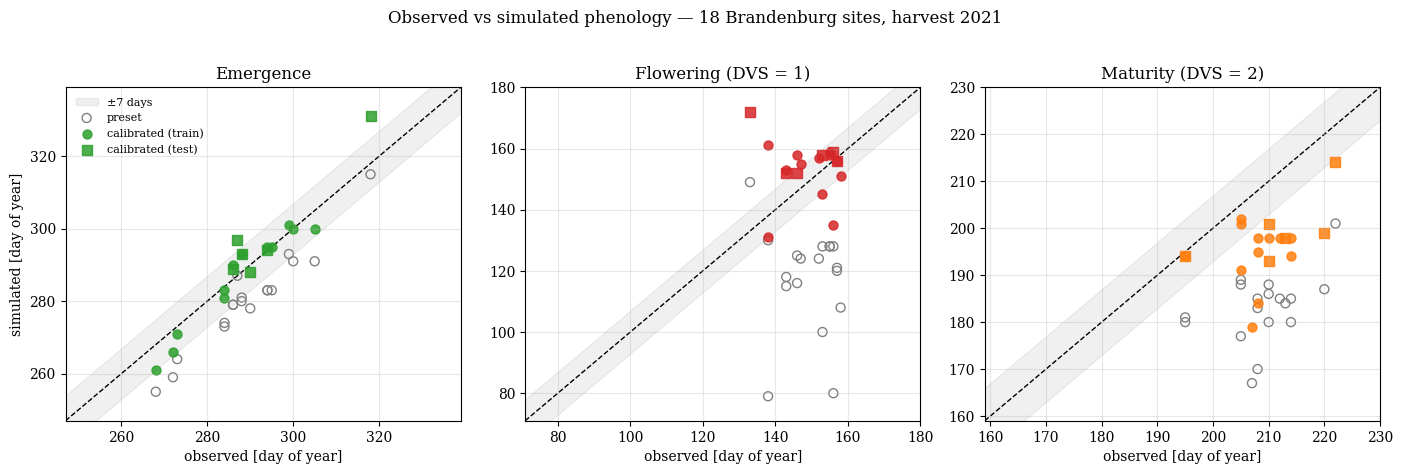

In [17]:
EVENT_STYLE = {
    "emergence": ("#2ca02c", "Emergence"),
    "flowering": ("#d62728", "Flowering (DVS = 1)"),
    "maturity": ("#ff7f0e", "Maturity (DVS = 2)"),
}


def to_doy(day_index):
    """Day index relative to ``SIM_START`` -> calendar day of year."""
    days = np.asarray(day_index, dtype=float)
    return (SIM_START + pd.to_timedelta(days, unit="D")).dayofyear.to_numpy()


fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))

for ax, event in zip(axes, EVENTS):
    colour, label = EVENT_STYLE[event]
    o = to_doy(observed_days[event].numpy())
    preset_doy = to_doy(baseline_days[event].numpy())
    fitted_doy = to_doy(calibrated_days[event].numpy())

    all_doy = np.concatenate([o, preset_doy, fitted_doy])
    span = np.array([all_doy.min() - 8, all_doy.max() + 8], dtype=float)

    ax.plot(span, span, ls="--", c="k", lw=1, zorder=0)
    ax.fill_between(span, span - 7, span + 7, color="k", alpha=0.06,
                    zorder=0, label="±7 days")
    ax.scatter(o, preset_doy, s=42, facecolor="none", edgecolor="grey",
               label="preset")
    for idx, marker, name in [(train_idx, "o", "calibrated (train)"),
                              (test_idx, "s", "calibrated (test)")]:
        ax.scatter(o[idx], fitted_doy[idx], s=42, marker=marker,
                   color=colour, alpha=0.85, label=name)

    ax.set_xlim(*span); ax.set_ylim(*span)
    ax.set_title(label); ax.set_xlabel("observed [day of year]")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("simulated [day of year]")
axes[0].legend(frameon=False, fontsize=8, loc="upper left")
fig.suptitle(
    f"Observed vs simulated phenology — {B} Brandenburg sites, harvest {HARVEST_YEAR}",
    y=1.02,
)
plt.tight_layout(); plt.show()

The preset points sit well below the 1:1 line (development too fast); the
calibrated ones straddle it, and the held-out sites scatter comparably to the
training sites — the fit is not absorbing noise. What remains is genuine
site-to-site variation in thermal requirement: the observed emergence-to-
flowering interval spans roughly 830–1590 °C d across these 18 regions, and one
shared `tsum1` cannot be right for all of them.


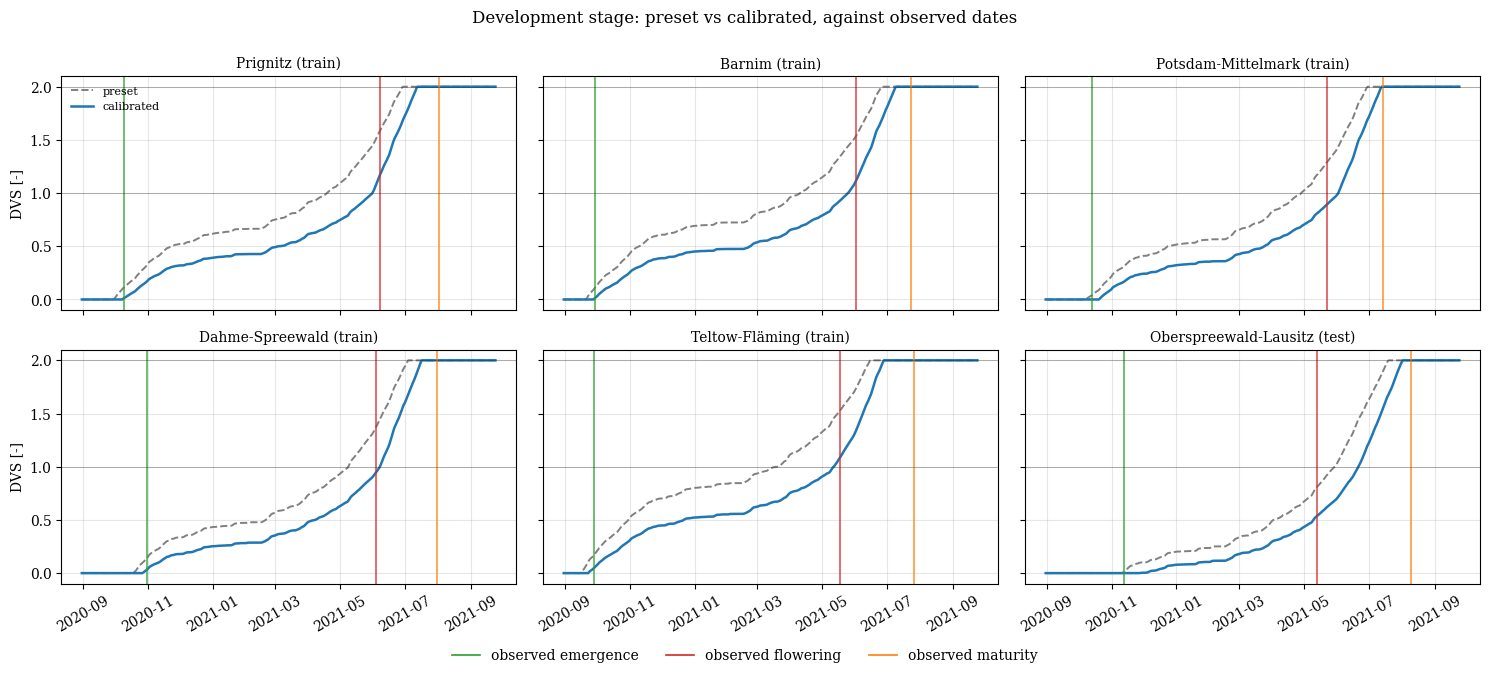

In [18]:
dates = pd.date_range(SIM_START, periods=T, freq="D")
selected = [0, 3, 7, 9, 13, 16]

fig, axes = plt.subplots(2, 3, figsize=(15, 6.4), sharex=True, sharey=True)

for ax, b in zip(axes.ravel(), selected):
    ax.plot(dates, baseline_dvs[b], color="grey", ls="--", lw=1.4, label="preset")
    ax.plot(dates, calibrated_dvs[b], color="#1f77b4", lw=1.8, label="calibrated")
    for event in EVENTS:
        colour, _ = EVENT_STYLE[event]
        observed_date = pd.to_datetime(obs[f"{event}_date"].iat[b])
        ax.axvline(observed_date, color=colour, lw=1.2, alpha=0.8)
    for level in (1.0, 2.0):
        ax.axhline(level, color="k", lw=0.6, alpha=0.3)

    split = "train" if b in train_idx.tolist() else "test"
    ax.set_title(f"{obs.NUTS_NAME.iat[b]} ({split})", fontsize=10)
    ax.grid(alpha=0.3)
    ax.tick_params(axis="x", rotation=30)

for ax in axes[:, 0]:
    ax.set_ylabel("DVS [-]")
axes[0, 0].legend(frameon=False, fontsize=8, loc="upper left")

handles = [plt.Line2D([], [], color=c, lw=1.2, label=f"observed {e}")
           for e, (c, _) in EVENT_STYLE.items()]
fig.legend(handles=handles, frameon=False, ncol=3, loc="lower center",
           bbox_to_anchor=(0.5, -0.04))
fig.suptitle("Development stage: preset vs calibrated, against observed dates", y=1.0)
plt.tight_layout(); plt.show()

The vertical lines are the observed dates. The dashed preset curve reaches
DVS 1 and DVS 2 well to the left of the red and orange lines; the calibrated
curve lands on them. The green emergence line is met by the flat pre-emergence
segment, whose length is set by `tsumem`.


## 9. Keeping the calibrated parameters

`named_values()` returns the fitted values as plain floats, which is all that
is needed to persist them — as a patch on a crop preset, or as the `init`
values of a follow-up calibration.


In [19]:
calibration_result = {
    "crop_name": "wheat",
    "region": "Brandenburg (DE4)",
    "harvest_year": HARVEST_YEAR,
    "parameters": {name: round(value, 1) for name, value in cal.named_values().items()},
    "train_rmse_days": round(history["rmse"][-1], 2),
}
calibration_result

{'crop_name': 'wheat',
 'region': 'Brandenburg (DE4)',
 'harvest_year': 2021,
 'parameters': {'crop.tsumem': 160.3,
  'crop.tsum1': 1394.7,
  'crop.tsum2': 821.3},
 'train_rmse_days': 11.1}

To reuse them, write the values straight onto a fresh parameter set:

```python
crop_params = CropParameters(crop_name="wheat")
for name, value in calibration_result["parameters"].items():
    setattr(crop_params, name.split(".")[1], torch.tensor(value))
```


## Summary

A complete phenology calibration in torchcrop is five moving parts:

| Step                | What it looks like                                                            |
| ------------------- | ----------------------------------------------------------------------------- |
| Observations        | event dates → day indices relative to the first simulated day                 |
| Sowing              | observed sowing DOY → `site_params.idpl` (a given, not a calibration target)  |
| Differentiable loss | `crossing_day` turns a DVS trajectory into a date that carries a gradient     |
| Problem definition  | `ParameterSpec` per free parameter; `CalibrationManager` owns the latents     |
| Optimization        | standard `torch.optim` loop with `cal.materialize()` before each forward pass |

Because the date error is differentiable all the way back to the crop
parameters, the fit needs no surrogate objective, no finite differences and no
outer search loop. Eighty gradient steps move flowering and maturity from a
month early onto the observations, and the held-out sites confirm the fit
generalises; the residual scatter is the site-to-site spread in thermal
requirement, not a shortcoming of the optimizer.

Natural extensions from here:

- **More seasons.** One year of weather constrains three parameters loosely;
  adding harvest years mainly sharpens `tsum1`.
- **Photoperiod and vernalisation.** Switching the preset to `IDSL = 2` brings
  `vernrt`, `vbase` and `versat` into play — table ordinates and ordered
  groups, which is exactly what the
  [constraint-aware calibration example](https://geonextgis.github.io/torchcrop/examples/04_calibration/calibration_%28winter_wheat%29/)
  covers.
- **Site-varying parameters.** `tsum1` may be a `[B]` tensor, giving each site
  its own thermal requirement — or a `ParameterNet` that predicts it from site
  covariates.
